<div align = "center">
<h1><b> Monitoring and Learning Agent </b></h1>
</div>

In [13]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Setting up the visualisation parameters
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11

In [14]:
# Load All Agent outputs
# Load tariff agent output
tariff_df = pd.read_csv(
    '../outputs/tariff_agent/tariff_recommendations.csv',
    parse_dates=['datetime']
)

# Load demand predictions
demand_df = pd.read_csv(
    '../outputs/demand_agent/demand_predictions.csv',
    parse_dates=['datetime']
)

# Load urban data for ground truth context
urban = pd.read_csv(
    '../data/processed/clean_urban_data.csv',
    parse_dates=['datetime']
)

# Load model scores
model_scores = pd.read_csv('../outputs/demand_agent/demand_model_scores.csv')

print("Tariff recommendations:", tariff_df.shape)
print("Demand predictions:    ", demand_df.shape)
print("Urban data:            ", urban.shape)
print("\nTariff columns:", tariff_df.columns.tolist())

# Key constants from Notebook 4
BASE_TARIFF         = 15.0
SURGE_THRESH        = 0.80
DISCOUNT_THRESH     = 0.30
SURGE_ELASTICITY    = -0.15
DISCOUNT_ELASTICITY = +0.20

Tariff recommendations: (411996, 14)
Demand predictions:     (411996, 13)
Urban data:             (2134080, 32)

Tariff columns: ['datetime', 'station_id', 'hour', 'day_of_week', 'is_weekend', 'predicted_utilization', 'dynamic_tariff', 'fixed_tariff', 'pricing_regime', 'energy_dynamic_kwh', 'revenue_dynamic', 'revenue_fixed', 'revenue_delta', 'adjusted_utilization']


In [24]:
# Define Evaluation Episodes
# ============================================================
# MONITORING & LEARNING AGENT
# Splits test period into episodes (1 day per episode)
# Evaluates each pricing decision against actual outcomes
# Tracks improvement of feedback loop over time
# ============================================================

# Sort by datetime
tariff_df = tariff_df.sort_values('datetime').reset_index(drop=True)

# Create episode labels — each episode = 1 days
tariff_df['date'] = tariff_df['datetime'].dt.date
unique_dates = sorted(tariff_df['date'].unique())

# Assign episode number (1 day per episode)
DAYS_PER_EPISODE = 1
date_to_episode  = {}
for i, date in enumerate(unique_dates):
    date_to_episode[date] = (i // DAYS_PER_EPISODE) + 1

tariff_df['episode'] = tariff_df['date'].map(date_to_episode)

n_episodes = tariff_df['episode'].nunique()
print(f"Total evaluation period: {tariff_df['datetime'].min()} → {tariff_df['datetime'].max()}")
print(f"Days per episode:        {DAYS_PER_EPISODE}")
print(f"Total episodes:          {n_episodes}")
print(f"\nEpisode distribution:")
print(tariff_df.groupby('episode')['date'].agg(['min','max','count']).to_string())

Total evaluation period: 2022-07-13 04:00:00 → 2022-07-18 22:55:00
Days per episode:        1
Total episodes:          6

Episode distribution:
                min         max  count
episode                               
1        2022-07-13  2022-07-13  59280
2        2022-07-14  2022-07-14  71136
3        2022-07-15  2022-07-15  71136
4        2022-07-16  2022-07-16  71136
5        2022-07-17  2022-07-17  71136
6        2022-07-18  2022-07-18  68172


In [16]:
# ============================================================
# Revenue & Pricing Efficiency per Episode
# ============================================================

# Step 1 — Check actual columns available
print("tariff_df columns:", tariff_df.columns.tolist())

# Step 2 — Revenue metrics from tariff_df
# tariff_df has: predicted_utilization, adjusted_utilization,
#                pricing_regime, revenue_dynamic, revenue_fixed

# Compute energy_dynamic_kwh if not present
AVG_CHARGERS_PER_STATION = 7.0   # from Notebook 4
AVG_KW_PER_CHARGER       = 7.0
SLOT_DURATION_HRS        = 5 / 60

if 'energy_dynamic_kwh' not in tariff_df.columns:
    tariff_df['energy_dynamic_kwh'] = (
        tariff_df['adjusted_utilization'] *
        AVG_CHARGERS_PER_STATION *
        AVG_KW_PER_CHARGER *
        SLOT_DURATION_HRS
    )

# Revenue metrics per episode
rev_episode = tariff_df.groupby('episode').apply(lambda ep: pd.Series({
    'total_revenue_dynamic': ep['revenue_dynamic'].sum(),
    'total_revenue_fixed':   ep['revenue_fixed'].sum(),
    'revenue_gain_pct':      ((ep['revenue_dynamic'].sum() - ep['revenue_fixed'].sum()) /
                               ep['revenue_fixed'].sum() * 100),
    'pricing_efficiency':    ep['revenue_dynamic'].sum() /
                             max(ep['energy_dynamic_kwh'].sum(), 0.001),
    'avg_dynamic_tariff':    ep['dynamic_tariff'].mean(),

    # Regime distribution — using correct column name
    'pct_surge':    (ep['pricing_regime'] == 'surge').mean()    * 100,
    'pct_baseline': (ep['pricing_regime'] == 'baseline').mean() * 100,
    'pct_discount': (ep['pricing_regime'] == 'discount').mean() * 100,

    'total_slots': len(ep)
})).reset_index()

print("\nRevenue metrics per episode:")
print(rev_episode[['episode','total_revenue_dynamic',
                    'revenue_gain_pct','pricing_efficiency']].to_string(index=False))

# Step 3 — Utilization metrics from util_df (correct column names)
util_df = pd.read_csv(
    '../outputs/tariff_agent/utilization_before_after.csv',
    parse_dates=['datetime']
)

print("\nutil_df columns:", util_df.columns.tolist())

# Assign episodes to util_df
util_df['date']    = util_df['datetime'].dt.date
util_df['episode'] = util_df['date'].map(date_to_episode)

# Drop rows where episode is NaN
# (dates in util_df that fall outside the test period)
util_df = util_df.dropna(subset=['episode'])
util_df['episode'] = util_df['episode'].astype(int)

# Utilization metrics per episode
util_episode = util_df.groupby('episode').apply(lambda ep: pd.Series({
    'avg_util_before':      ep['utilization_before'].mean(),
    'avg_util_after':       ep['utilization_after'].mean(),
    'pct_congested_before': (ep['utilization_before'] > SURGE_THRESH).mean() * 100,
    'pct_congested_after':  (ep['utilization_after']  > SURGE_THRESH).mean() * 100,
    'pct_underutil_before': (ep['utilization_before'] < DISCOUNT_THRESH).mean() * 100,
    'pct_underutil_after':  (ep['utilization_after']  < DISCOUNT_THRESH).mean() * 100,
})).reset_index()

print("\nUtilization metrics per episode:")
print(util_episode.to_string(index=False))

# Store episode_metrics as combined
episode_metrics = rev_episode.copy()
print("\nCell 4 complete")

tariff_df columns: ['datetime', 'station_id', 'hour', 'day_of_week', 'is_weekend', 'predicted_utilization', 'dynamic_tariff', 'fixed_tariff', 'pricing_regime', 'energy_dynamic_kwh', 'revenue_dynamic', 'revenue_fixed', 'revenue_delta', 'adjusted_utilization', 'date', 'episode']

Revenue metrics per episode:
 episode  total_revenue_dynamic  revenue_gain_pct  pricing_efficiency
       1           1.106717e+07          5.661245           14.712241
       2           1.376562e+07          5.018720           14.741172
       3           1.384094e+07          4.857864           14.749316
       4           1.413999e+07          4.984438           14.767694
       5           1.394321e+07          5.167272           14.759076
       6           1.316146e+07          5.432235           14.736268

util_df columns: ['datetime', 'station_id', 'hour', 'regime', 'utilization_before', 'utilization_after', 'utilization_change']

Utilization metrics per episode:
 episode  avg_util_before  avg_util_afte

In [17]:
# Computation of Wait Time Reduction per Episode
'''
Wait time is the most tangible user-facing metric. Congested slots directly translate to 
queuing — each 5-minute slot where a station is above 80% represents 5 minutes a user 
potentially waits. Reducing congested slot-minutes is a direct proxy for reducing user wait time
'''

SLOT_DURATION_MIN = 5

wait_metrics = util_df.groupby('episode').apply(lambda ep: pd.Series({
    'congested_slot_mins_before': (ep['utilization_before'] > SURGE_THRESH).sum() * SLOT_DURATION_MIN,
    'congested_slot_mins_after':  (ep['utilization_after']  > SURGE_THRESH).sum() * SLOT_DURATION_MIN,
    'wait_time_reduction_mins':   (
        (ep['utilization_before'] > SURGE_THRESH).sum() -
        (ep['utilization_after']  > SURGE_THRESH).sum()
    ) * SLOT_DURATION_MIN,
    'wait_reduction_pct': (
        ((ep['utilization_before'] > SURGE_THRESH).sum() -
         (ep['utilization_after']  > SURGE_THRESH).sum()) /
         max((ep['utilization_before'] > SURGE_THRESH).sum(), 1) * 100
    )
})).reset_index()

print("Wait time metrics per episode:")
print(wait_metrics.to_string(index=False))

Wait time metrics per episode:
 episode  congested_slot_mins_before  congested_slot_mins_after  wait_time_reduction_mins  wait_reduction_pct
       1                      1520.0                      235.0                    1285.0           84.539474
       2                      2405.0                       80.0                    2325.0           96.673597
       3                      2315.0                      155.0                    2160.0           93.304536
       4                      1985.0                      375.0                    1610.0           81.108312
       5                      2455.0                      315.0                    2140.0           87.169043
       6                      1815.0                      450.0                    1365.0           75.206612


In [18]:
# Customer Response Rate per Episode
# Computes avg. utilization change per episode for all slots and customer response rate

response_metrics = util_df.groupby('episode').apply(lambda ep: pd.Series({
    'avg_util_change': (ep['utilization_after'] - ep['utilization_before']).mean(),
    'customer_response_rate': (
        abs(ep['utilization_after'] - ep['utilization_before']).mean() /
        max(ep['utilization_before'].mean(), 0.001) * 100
    )
})).reset_index()

print("Customer response metrics per episode:")
print(response_metrics[['episode','avg_util_change',
                          'customer_response_rate']].to_string(index=False))

Customer response metrics per episode:
 episode  avg_util_change  customer_response_rate
       1         0.019140                7.419328
       2         0.017700                6.757113
       3         0.017246                6.533743
       4         0.017600                6.445980
       5         0.017958                6.778598
       6         0.018783                7.052175


In [19]:
# Merge All Episode Metrics
'''Merges revenue metrics, utilization metrics, wait time metrics, and customer response 
metrics into  a single all_metrics dataframe — one row per episode'''

all_metrics = rev_episode.merge(util_episode,    on='episode', how='left')
all_metrics = all_metrics.merge(wait_metrics,    on='episode', how='left')
all_metrics = all_metrics.merge(
    response_metrics[['episode','customer_response_rate']],
    on='episode', how='left'
)

print("Combined metrics shape:", all_metrics.shape)
print("\nAll episode metrics:")
print(all_metrics[[
    'episode', 'revenue_gain_pct', 'pricing_efficiency',
    'wait_time_reduction_mins', 'customer_response_rate'
]].to_string(index=False))

Combined metrics shape: (6, 21)

All episode metrics:
 episode  revenue_gain_pct  pricing_efficiency  wait_time_reduction_mins  customer_response_rate
       1          5.661245           14.712241                    1285.0                7.419328
       2          5.018720           14.741172                    2325.0                6.757113
       3          4.857864           14.749316                    2160.0                6.533743
       4          4.984438           14.767694                    1610.0                6.445980
       5          5.167272           14.759076                    2140.0                6.778598
       6          5.432235           14.736268                    1365.0                7.052175


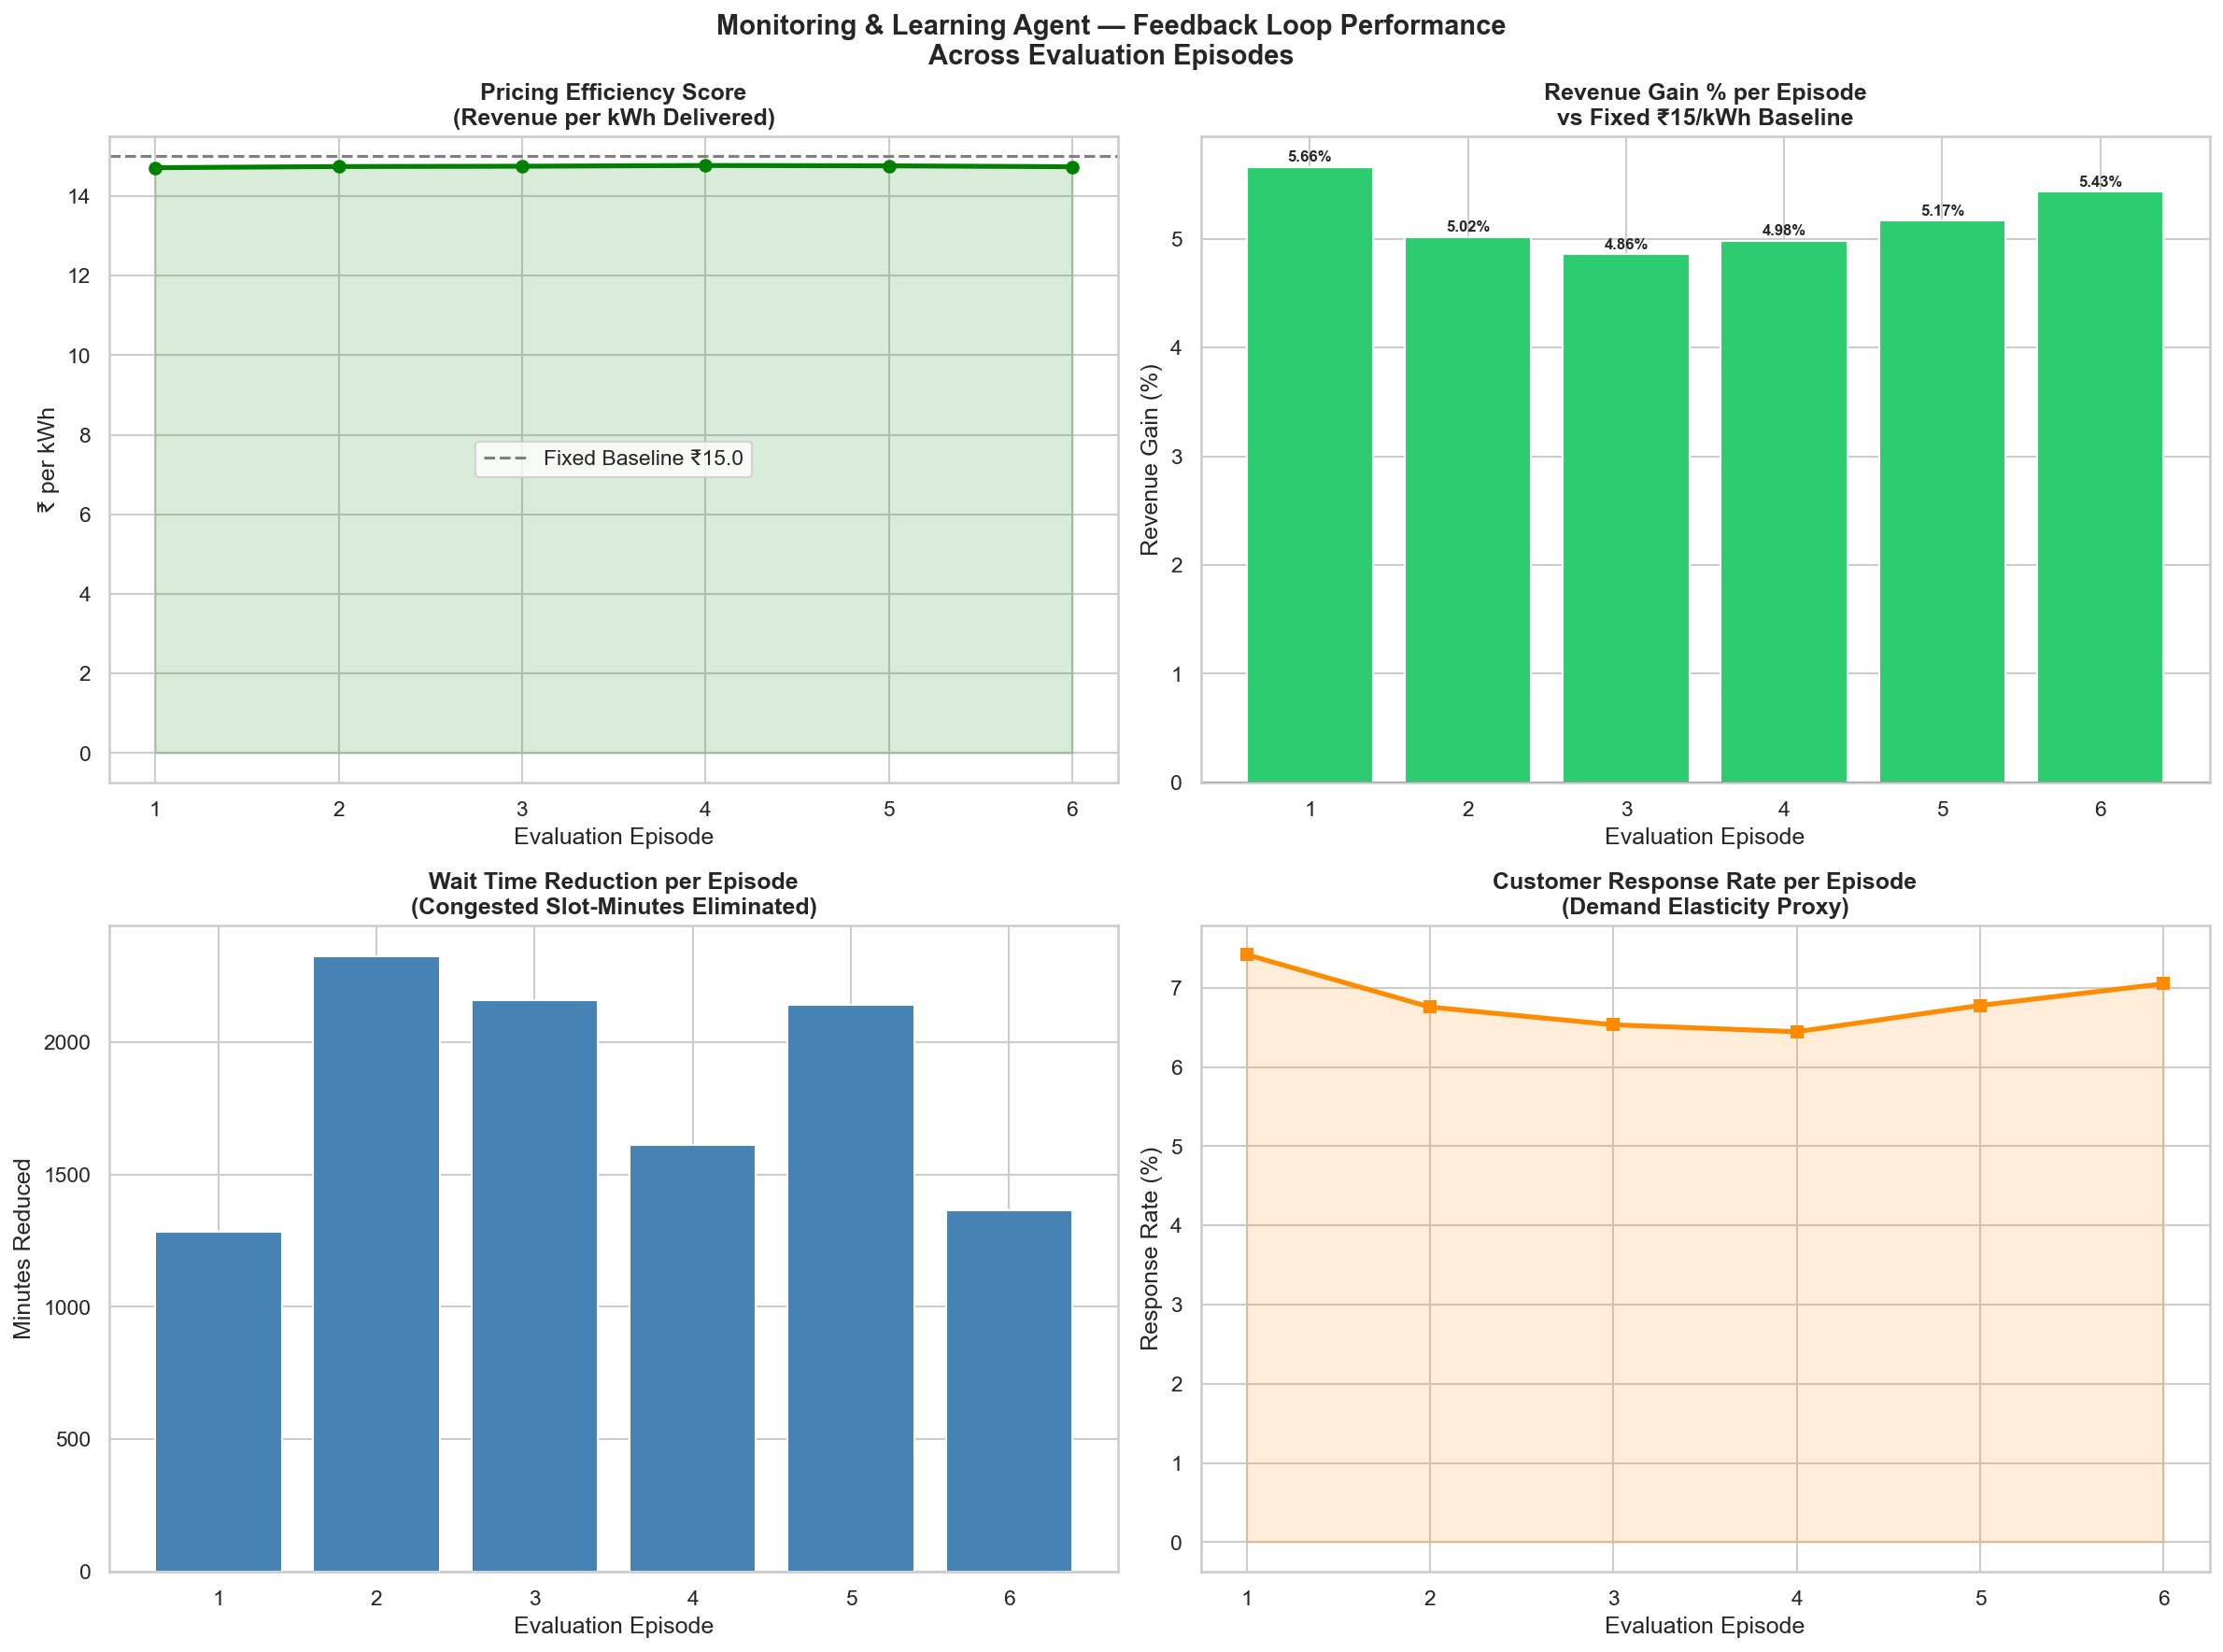

Saved: feedback_loop_improvement.png


In [20]:
# Feedback loop visualisation: Demonstrate the feedback loop working.

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

episodes = all_metrics['episode']

# 1. Pricing Efficiency over episodes
axes[0,0].plot(episodes, all_metrics['pricing_efficiency'],
               marker='o', color='green', linewidth=2.5)
axes[0,0].fill_between(episodes, all_metrics['pricing_efficiency'],
                        alpha=0.15, color='green')
axes[0,0].set_title('Pricing Efficiency Score\n(Revenue per kWh Delivered)',
                     fontweight='bold')
axes[0,0].set_xlabel('Evaluation Episode')
axes[0,0].set_ylabel('₹ per kWh')
axes[0,0].axhline(BASE_TARIFF, color='gray', linestyle='--',
                   linewidth=1.5, label=f'Fixed Baseline ₹{BASE_TARIFF}')
axes[0,0].legend()

# 2. Revenue Gain % over episodes
colors_gain = ['#2ecc71' if g > 0 else '#e74c3c'
               for g in all_metrics['revenue_gain_pct']]
axes[0,1].bar(episodes, all_metrics['revenue_gain_pct'],
              color=colors_gain, edgecolor='white')
axes[0,1].axhline(0, color='black', linewidth=1)
axes[0,1].set_title('Revenue Gain % per Episode\nvs Fixed ₹15/kWh Baseline',
                     fontweight='bold')
axes[0,1].set_xlabel('Evaluation Episode')
axes[0,1].set_ylabel('Revenue Gain (%)')
for i, (ep, val) in enumerate(zip(episodes, all_metrics['revenue_gain_pct'])):
    axes[0,1].text(ep, val + 0.05 if val >= 0 else val - 0.15,
                   f'{val:.2f}%', ha='center', fontsize=8, fontweight='bold')

# 3. Wait Time Reduction over episodes
axes[1,0].bar(episodes, all_metrics['wait_time_reduction_mins'],
              color='steelblue', edgecolor='white')
axes[1,0].set_title('Wait Time Reduction per Episode\n(Congested Slot-Minutes Eliminated)',
                     fontweight='bold')
axes[1,0].set_xlabel('Evaluation Episode')
axes[1,0].set_ylabel('Minutes Reduced')

# 4. Customer Response Rate over episodes
axes[1,1].plot(episodes, all_metrics['customer_response_rate'],
               marker='s', color='darkorange', linewidth=2.5)
axes[1,1].fill_between(episodes, all_metrics['customer_response_rate'],
                        alpha=0.15, color='darkorange')
axes[1,1].set_title('Customer Response Rate per Episode\n(Demand Elasticity Proxy)',
                     fontweight='bold')
axes[1,1].set_xlabel('Evaluation Episode')
axes[1,1].set_ylabel('Response Rate (%)')

plt.suptitle('Monitoring & Learning Agent — Feedback Loop Performance\nAcross Evaluation Episodes',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/monitoring_agent/feedback_loop_improvement.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feedback_loop_improvement.png")

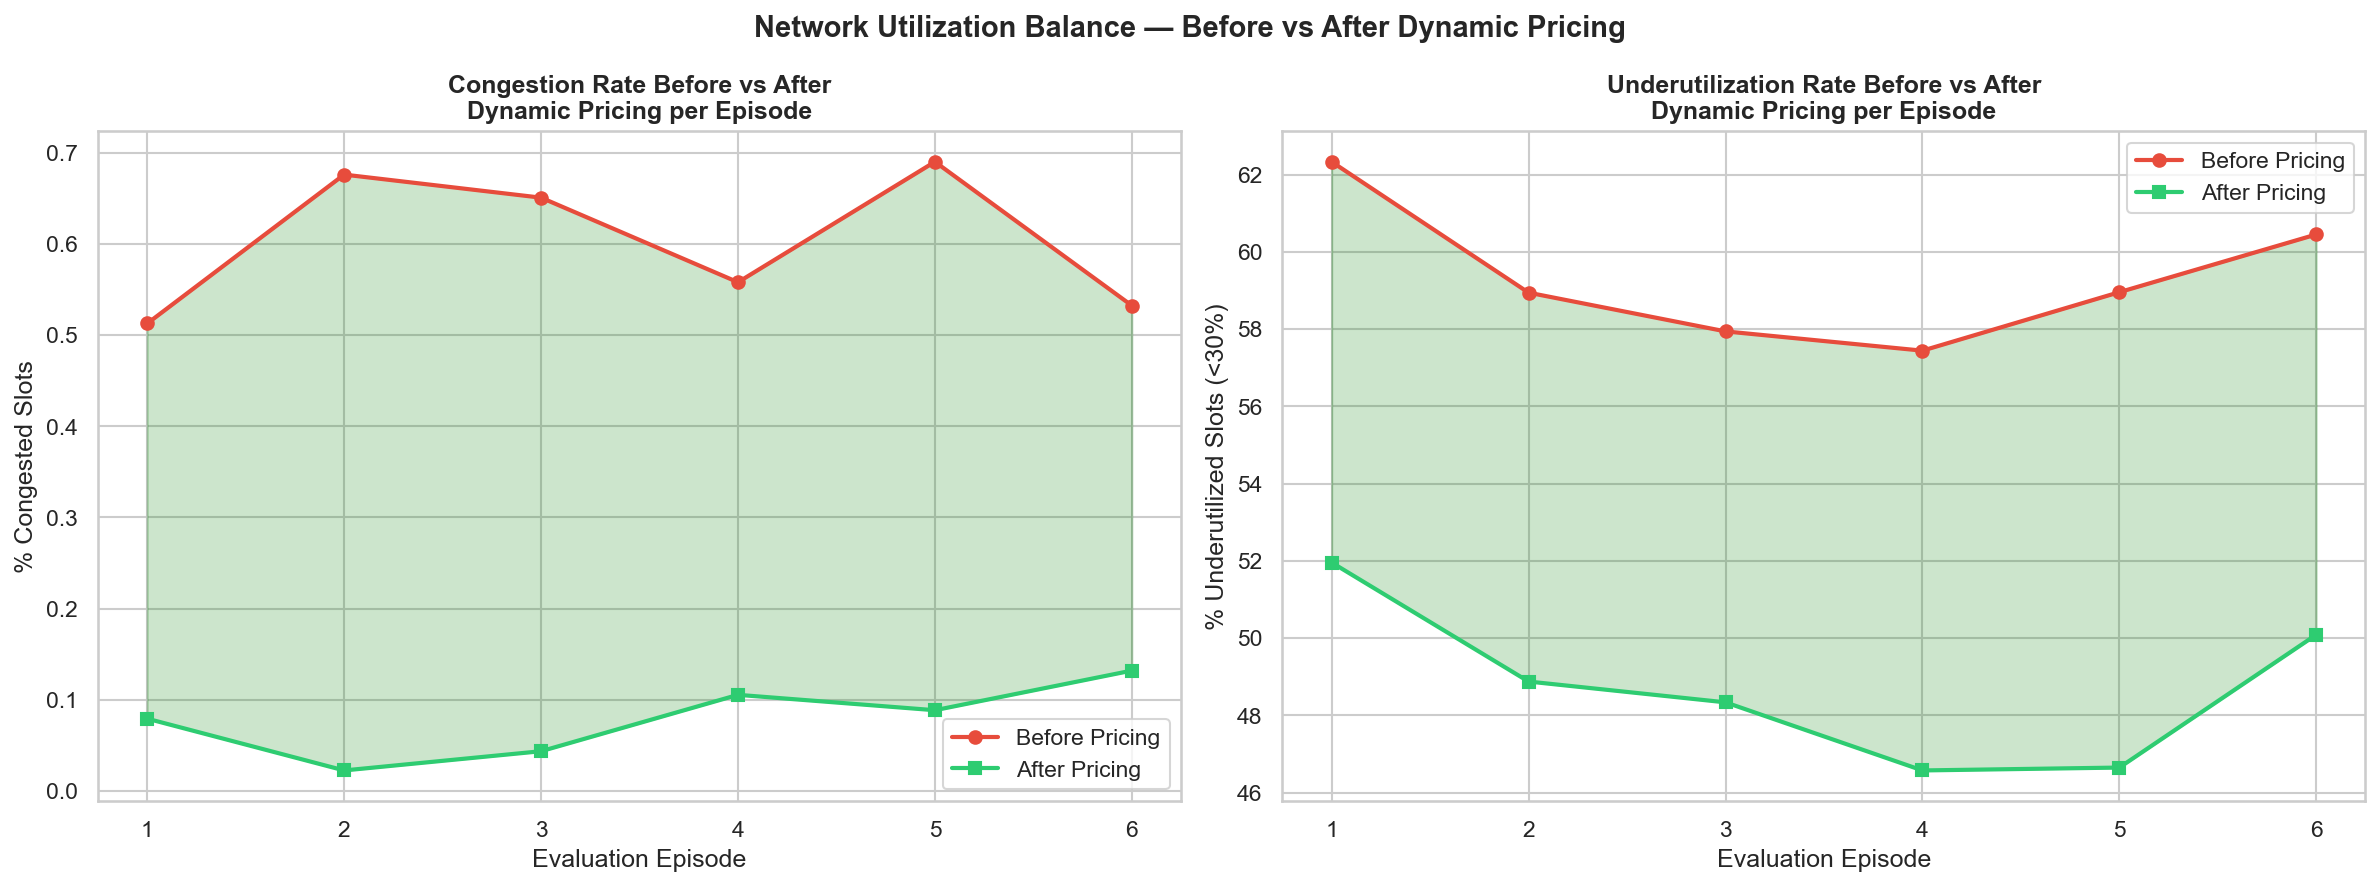

Saved: utilization_balance.png


In [21]:
# utilisation balance improvement
# These charts show the demand balancing effect of dynamic pricing across episodes. 

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Congestion reduction per episode
axes[0].plot(episodes, all_metrics['pct_congested_before'],
             marker='o', color='#e74c3c', linewidth=2, label='Before Pricing')
axes[0].plot(episodes, all_metrics['pct_congested_after'],
             marker='s', color='#2ecc71', linewidth=2, label='After Pricing')
axes[0].fill_between(episodes,
                      all_metrics['pct_congested_before'],
                      all_metrics['pct_congested_after'],
                      alpha=0.2, color='green')
axes[0].set_title('Congestion Rate Before vs After\nDynamic Pricing per Episode',
                   fontweight='bold')
axes[0].set_xlabel('Evaluation Episode')
axes[0].set_ylabel('% Congested Slots')
axes[0].legend()

# Underutilization reduction per episode
axes[1].plot(episodes, all_metrics['pct_underutil_before'],
             marker='o', color='#e74c3c', linewidth=2, label='Before Pricing')
axes[1].plot(episodes, all_metrics['pct_underutil_after'],
             marker='s', color='#2ecc71', linewidth=2, label='After Pricing')
axes[1].fill_between(episodes,
                      all_metrics['pct_underutil_before'],
                      all_metrics['pct_underutil_after'],
                      alpha=0.2, color='green')
axes[1].set_title('Underutilization Rate Before vs After\nDynamic Pricing per Episode',
                   fontweight='bold')
axes[1].set_xlabel('Evaluation Episode')
axes[1].set_ylabel('% Underutilized Slots (<30%)')
axes[1].legend()

plt.suptitle('Network Utilization Balance — Before vs After Dynamic Pricing',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/monitoring_agent/utilization_balance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: utilization_balance.png")

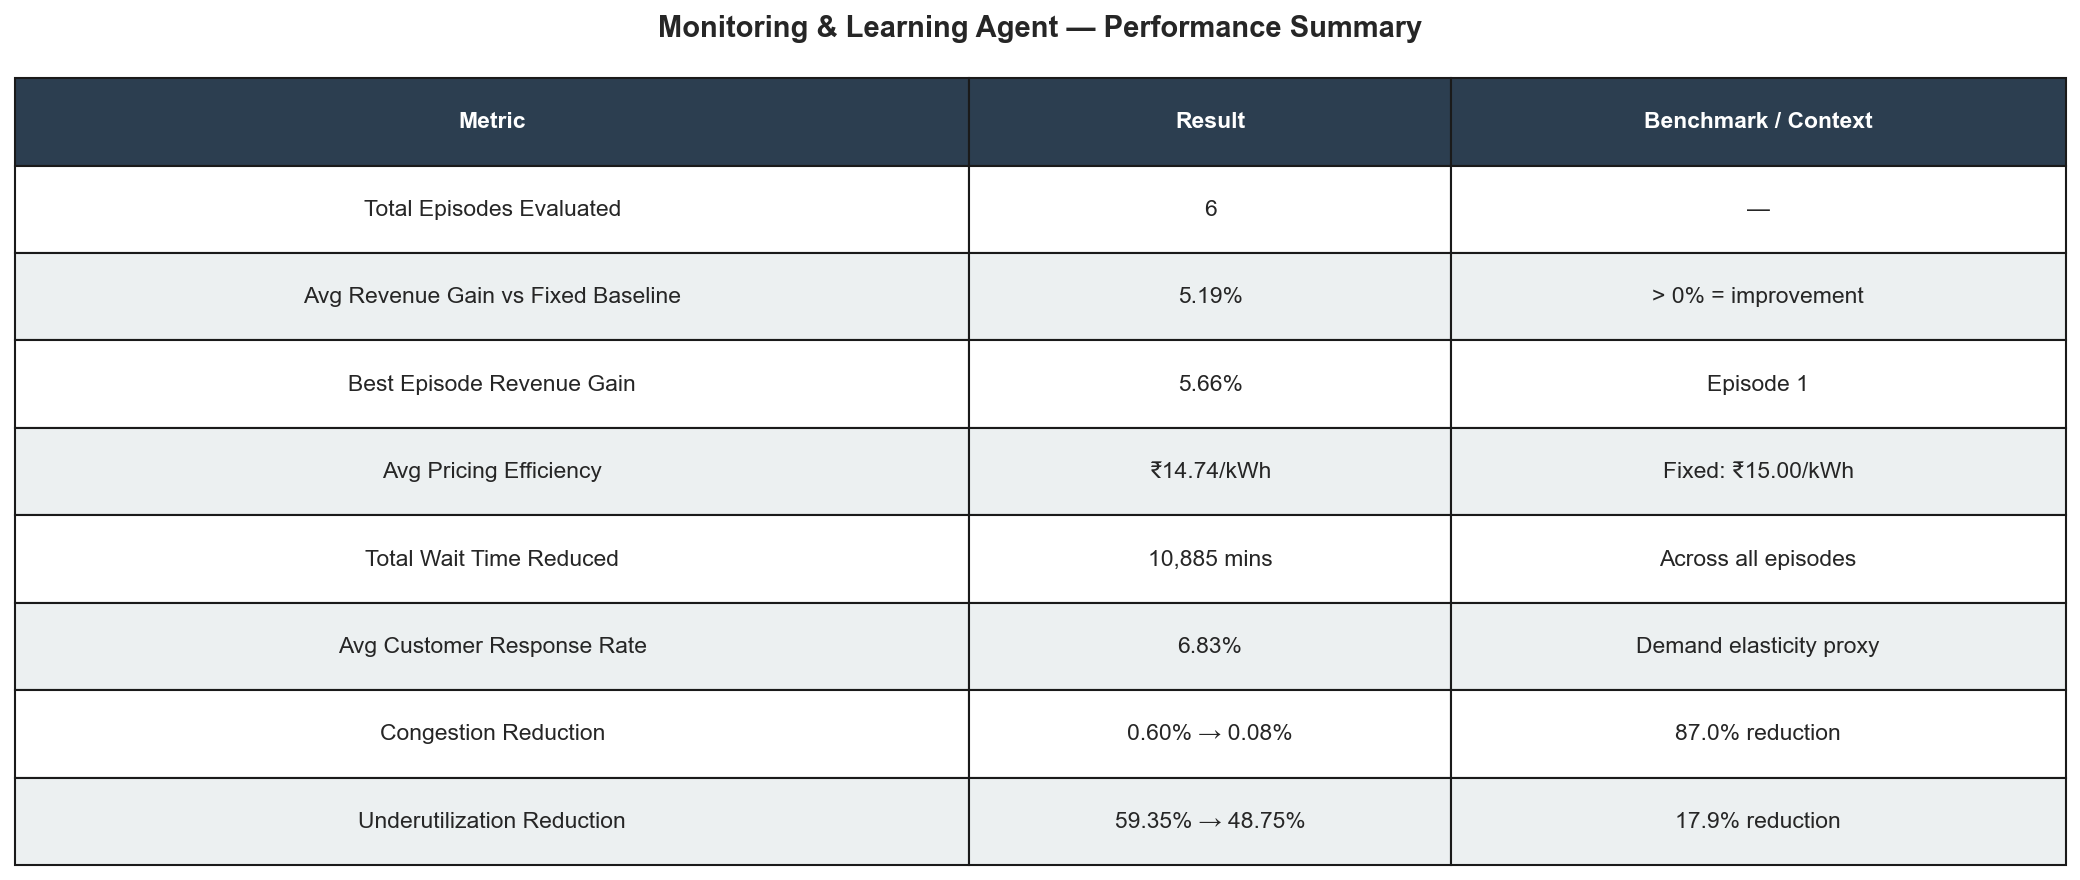

Saved: agent_summary_dashboard.png


In [22]:
# Monitoring and Learning Agent Performance Summary Dashboard
fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')

# Build summary table
summary_data = [
    ['Total Episodes Evaluated',
     str(n_episodes), '—'],

    ['Avg Revenue Gain vs Fixed Baseline',
     f"{all_metrics['revenue_gain_pct'].mean():.2f}%",
     '> 0% = improvement'],

    ['Best Episode Revenue Gain',
     f"{all_metrics['revenue_gain_pct'].max():.2f}%",
     f"Episode {all_metrics['revenue_gain_pct'].idxmax()+1}"],

    ['Avg Pricing Efficiency',
     f"₹{all_metrics['pricing_efficiency'].mean():.2f}/kWh",
     f"Fixed: ₹{BASE_TARIFF:.2f}/kWh"],

    ['Total Wait Time Reduced',
     f"{all_metrics['wait_time_reduction_mins'].sum():,.0f} mins",
     'Across all episodes'],

    ['Avg Customer Response Rate',
     f"{all_metrics['customer_response_rate'].mean():.2f}%",
     'Demand elasticity proxy'],

    ['Congestion Reduction',
     f"{all_metrics['pct_congested_before'].mean():.2f}% → "
     f"{all_metrics['pct_congested_after'].mean():.2f}%",
     f"{((all_metrics['pct_congested_before'].mean() - all_metrics['pct_congested_after'].mean()) / max(all_metrics['pct_congested_before'].mean(),0.001) * 100):.1f}% reduction"],

    ['Underutilization Reduction',
     f"{all_metrics['pct_underutil_before'].mean():.2f}% → "
     f"{all_metrics['pct_underutil_after'].mean():.2f}%",
     f"{((all_metrics['pct_underutil_before'].mean() - all_metrics['pct_underutil_after'].mean()) / max(all_metrics['pct_underutil_before'].mean(),0.001) * 100):.1f}% reduction"],
]

table = ax.table(
    cellText=summary_data,
    colLabels=['Metric', 'Result', 'Benchmark / Context'],
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.auto_set_column_width([0, 1, 2])

# Style header
for j in range(3):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Alternate row colors
for i in range(1, len(summary_data) + 1):
    for j in range(3):
        table[i, j].set_facecolor('#ecf0f1' if i % 2 == 0 else 'white')

ax.set_title('Monitoring & Learning Agent — Performance Summary',
              fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('../visuals/monitoring_agent/agent_summary_dashboard.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: agent_summary_dashboard.png")

In [23]:
# Export All Monitoring and Learning Agent CSV
# 1. Full episode performance metrics
all_metrics.to_csv(
    '../outputs/monitoring_agent/agent_performance_metrics.csv',
    index=False
)
print("Saved: agent_performance_metrics.csv →", all_metrics.shape)

# 2. Feedback loop improvement (key metrics over episodes)
feedback_df = all_metrics[[
    'episode',
    'revenue_gain_pct',
    'pricing_efficiency',
    'wait_time_reduction_mins',
    'customer_response_rate',
    'pct_congested_before',
    'pct_congested_after',
    'pct_underutil_before',
    'pct_underutil_after'
]].round(4)
feedback_df.to_csv(
    '../outputs/monitoring_agent/feedback_loop_improvement.csv',
    index=False
)
print("Saved: feedback_loop_improvement.csv →", feedback_df.shape)

# Print final summary
print("\n" + "="*55)
print("         MONITORING AGENT — FINAL SUMMARY")
print("="*55)
print(f"  Episodes evaluated:        {n_episodes}")
print(f"  Avg revenue gain:          {all_metrics['revenue_gain_pct'].mean():.2f}%")
print(f"  Avg pricing efficiency:    ₹{all_metrics['pricing_efficiency'].mean():.2f}/kWh")
print(f"  Total wait time reduced:   {all_metrics['wait_time_reduction_mins'].sum():,.0f} mins")
print(f"  Avg customer response:     {all_metrics['customer_response_rate'].mean():.2f}%")
print(f"  Congestion:                {all_metrics['pct_congested_before'].mean():.2f}% → {all_metrics['pct_congested_after'].mean():.2f}%")
print(f"  Underutilization:          {all_metrics['pct_underutil_before'].mean():.2f}% → {all_metrics['pct_underutil_after'].mean():.2f}%")
print("="*55)
print("\nNotebook 5 Complete!")

Saved: agent_performance_metrics.csv → (6, 21)
Saved: feedback_loop_improvement.csv → (6, 9)

         MONITORING AGENT — FINAL SUMMARY
  Episodes evaluated:        6
  Avg revenue gain:          5.19%
  Avg pricing efficiency:    ₹14.74/kWh
  Total wait time reduced:   10,885 mins
  Avg customer response:     6.83%
  Congestion:                0.60% → 0.08%
  Underutilization:          59.35% → 48.75%

Notebook 5 Complete!
